FODO - Focusing-Drift-Defocusing-Drift

In [1]:
from sympy import *

f, d, x, px = symbols('f d x px')

Focusing = Matrix([[1,0],[-1/f,1]])
Drift = Matrix([[1,d],[0,1]])
Defocusing = Matrix([[1,0],[1/f,1]])

print('Focusing, Drift, Defocusing:')
display(Focusing, Drift, Defocusing)

print('beamline: FODO')
FODO = MatMul(Drift,Defocusing,Drift,Focusing, evaluate=False)
display(FODO)
display(FODO.doit())

Focusing, Drift, Defocusing:


Matrix([
[   1, 0],
[-1/f, 1]])

Matrix([
[1, d],
[0, 1]])

Matrix([
[  1, 0],
[1/f, 1]])

beamline: FODO


Matrix([
[1, d],
[0, 1]])*Matrix([
[  1, 0],
[1/f, 1]])*Matrix([
[1, d],
[0, 1]])*Matrix([
[   1, 0],
[-1/f, 1]])

Matrix([
[d/f + 1 - (d*(d/f + 1) + d)/f, d*(d/f + 1) + d],
[           -(d/f + 1)/f + 1/f,         d/f + 1]])

In [11]:
f_1, f_2, d_1, d_2 = symbols('f1:3 l1:3')

F1 = Focusing.replace(f,f_1)
D2 = Defocusing.replace(f,f_2) #f2 > 0
O1 = Drift.replace(d,d_1)
O2 = Drift.replace(d,d_2)

print('beamline, variable focus/length:')
variable_FODO = MatMul(O2,D2,O1,F1, evaluate=False)
display(variable_FODO)
display(variable_FODO.doit())
display(variable_FODO.doit().expand())

beamline, variable focus/length:


Matrix([
[1, l2],
[0,  1]])*Matrix([
[   1, 0],
[1/f2, 1]])*Matrix([
[1, l1],
[0,  1]])*Matrix([
[    1, 0],
[-1/f1, 1]])

Matrix([
[1 + l2/f2 - (l1*(1 + l2/f2) + l2)/f1, l1*(1 + l2/f2) + l2],
[               1/f2 - (1 + l1/f2)/f1,           1 + l1/f2]])

Matrix([
[1 + l2/f2 - l1/f1 - l2/f1 - l1*l2/(f1*f2), l1 + l2 + l1*l2/f2],
[                 1/f2 - 1/f1 - l1/(f1*f2),          1 + l1/f2]])

Imaging definition: Point to Point. Must take data from one small point to one small point. $\langle x|m \rangle = 0 $

Cameras have no angular dependence (top right of matrix).

In [3]:
camera = O2 * F1 * O1
camera.simplify()
no_angle_dependence = Eq(camera.row(0)[1], 0)
mag = camera.row(0)[0]
display(Eq(f_1,solve(no_angle_dependence,f_1)[0]))
display(mag.replace(f_1,solve(no_angle_dependence,f_1)[0]).simplify())

Eq(f1, l1*l2/(l1 + l2))

-l2/l1

Parallel-to-Point: Final position depends on initial angle not initial position. Top left value is zero. Human eye. Can e done with one lens
$\langle x | x \rangle = 0$

Point-to-parallel: microscope. $\langle m | m \rangle = 0$

Parallel-to-parallel. Telescope, accelerator $\langle m | x \rangle = 0$. Magnification is now $\langle m | m \rangle$

Example with Focus Lens - Drift - Focus (LDL)

In [4]:
F2 = Focusing.replace(f,f_2)
M = MatMul(F2,O1,F1, evaluate=False)
print('optics setup: LDL')
display(M)
display(M.doit())
display(M.doit().simplify())
# zero requirement
print('Parallel-to-parallel (m,x)=0 requirement:')
display(Eq(d_1,solve(M.doit().row(1)[0], d_1)[0])) # confirm condition on length

print('focusing (m|m):')
Mag = M.doit().row(1)[1]
Mag.replace(d_1,solve(M.doit().row(1)[0], d_1)[0]).simplify() # confirm mag - one mag must defocus

optics setup: LDL


Matrix([
[    1, 0],
[-1/f2, 1]])*Matrix([
[1, l1],
[0,  1]])*Matrix([
[    1, 0],
[-1/f1, 1]])

Matrix([
[             1 - l1/f1,        l1],
[-1/f2 - (1 - l1/f2)/f1, 1 - l1/f2]])

Matrix([
[           (f1 - l1)/f1,           l1],
[(-f1 - f2 + l1)/(f1*f2), (f2 - l1)/f2]])

Parallel-to-parallel (m,x)=0 requirement:


Eq(l1, f1 + f2)

focusing (m|m):


-f1/f2

https://www.classe.cornell.edu/bmad/

Bmad notes: cuz if you don't write it down it's leaving ya brain.

Chapter 7/8

```Tao
show plot -templates ! show is based

set curve beta draw_symbols = True ! set <class> <specific instance> <parameter> = <value>
set graph floor_plan y%min = -2 ! works for like any class
```

Feels like `x_scale` isn't great with `floor_plan`. In fact, I wish everything was controlled by `set`.

Chapter 9

<br>Design lattice - a file that can be loaded
<br>Model lattice - working / edit in progress. Can load in design. Mostly the active piece
<br>Base lattice - values set via model lattice. Kind of a quicksave. `set lattice base = model`

`change` feels a bit archaic. 

Chapter 10

<br>data - the thing that is measured / optimized
<br>variables - the thing that is changed

The d2/d1 thing is just a way to specify category, then type, then example of what is being optimized. Not sure why category is needed if each type belongs in a unique category but whatever. Maybe We are explicitly telling it to store/accept certain types? 

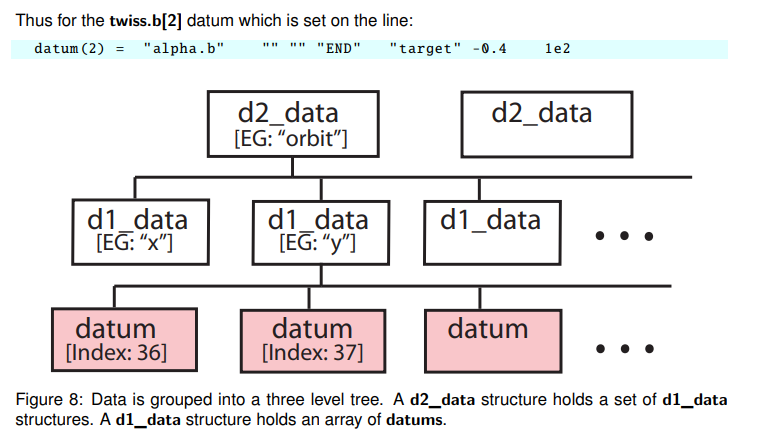

- Is quadrupole $k1$ related to $f$ in class? $KL = 1/f$
- Envelope vs particle sim in bmad. I noticed `particle_start` has emittance parameters
- We talked about rms emittance, I saw on wikipedia there are other kinds. Do we just choose whatever feels nice to work with?

more specific questions:
- noticed use, b2 appears twice in provided file `triplet.bmad`

---
 2/3/2026
---

### Review of last week

$$
    \beta \gamma - \alpha^2 = 1
\\  \alpha = - {\braket{xx'} \over \epsilon / \pi}\quad \text{angle-amplitude tilt}
\\  \beta = {\braket{x^2} \over \epsilon / \pi}\quad \text{amplitude function}
\\  \gamma = {\braket{x'^2} \over \epsilon / \pi} \quad \text{angle metric}
\\  \epsilon = \pi \sqrt{\braket{x^2}\braket{x'^2}-\braket{xx'}^2}
$$
Phase advance: $\psi' = 1 / \beta$. See visual below.

![Screenshot 2026-02-03 114312.png](<attachment:Screenshot 2026-02-03 114312.png>)

### Tune and stability

Tune is the number of full rotations around the phase space plot that a particle makes while traveling around a circular accelerator / storage ring. For example: tune of $4$ implies $4$ flip/flops of the amplitude function $\beta$. Integer tunes cause particles to always follow the same path, while non-integer or irrational tune will cause particles to always follow different paths through elemnts.

Nonlinearities throw particles off the ideal track that we derive from optics, so non-integer tune is preferred to avoid nonlinear effects stacking with each journey around the ring. We're going to talk more about nonlinearity later in the semester.

Tune can be derived from this slide:

![Screenshot 2026-02-03 122117.png](<attachment:Screenshot 2026-02-03 122117.png>)

### Beam mismatch

Slides 36-41

Real twiss parameters $\neq$ parameters needed by machine. Due to nonlinearities we dropped out of Hill's equation and variation of phase advance with $\phi' = 1/\beta$, the beam will spread out and emittance will increase (slide 39). 

### Imaging Project


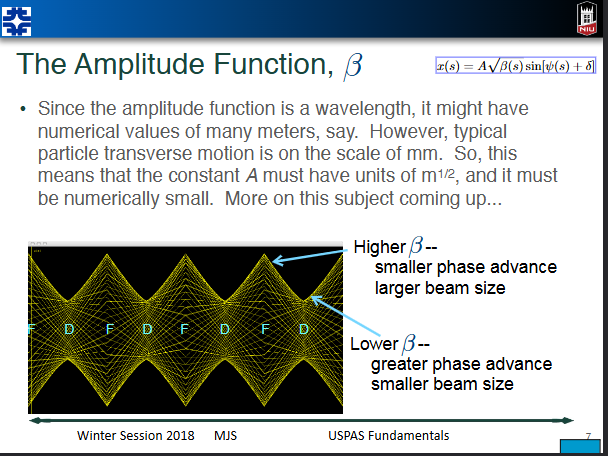
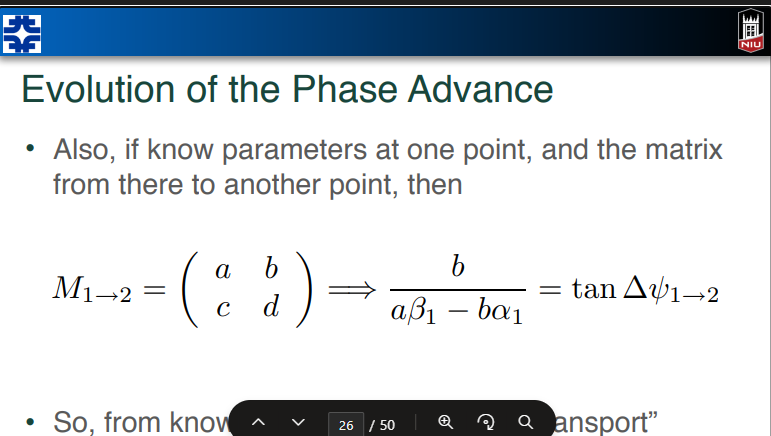

The `r` data is unrelated to the particle initial values `px` and `py`

---
 2/10/26
---

Modules.

Quadrupole FODO with dipole bending at peak beta.

Telescopic systems for small beam at IP, parallel to parallel.

In [5]:
# run notebook first
O1_f = Drift.replace(d,f_1)
O2_f = Drift.replace(d,f_2)


Telescope = MatMul(O1_f,F1,O1_f,O2_f,F2,O2_f, evaluate=False)
tscope_transfer = Telescope.doit().simplify()
tscope_transfer

Matrix([
[-f1/f2,      0],
[     0, -f2/f1]])

Use generalized twiss propogation:

$$
\begin{pmatrix}
\beta \\ \alpha \\ \gamma
\end{pmatrix}
=
\begin{bmatrix}
    C^2 & -2SC & S^2 
\\  -CC' & (S'C+SC') & -SS'
\\  C'^2 & -2S'C' & S'^2
\end{bmatrix}
\begin{pmatrix}
\beta_0 \\ \alpha_0 \\ \gamma_0
\end{pmatrix}
$$
Where the transfer matrix is
$$
\begin{bmatrix}
C & S \\ C' & S'
\end{bmatrix}
$$
this gives the twiss evolution of a telescope as


We also know from our $\tan \Delta \psi$ equation that $\Delta \psi = \pi$

In [6]:
S, C, Sp, Cp = symbols('S C S\' C\' ')

Twiss_Propogation_Matrix = Matrix([
    [C*C, -2*S*C, S*S],
    [-C*Cp, Sp*C + S*C, -S*Sp],
    [Cp*Cp, -2*Sp*Cp, Sp*Sp]
    ])

display(Twiss_Propogation_Matrix)

def transfer_to_twiss(transfer_matrix):
    '''Twiss 1D Parameter Evolution Matrix'''

    [[a,b],[c,d]] = transfer_matrix.tolist()
    parameters = {
        C: a,
        S: b,
        Cp: c,
        Sp: d
        }
    result = Twiss_Propogation_Matrix.subs(parameters)
    return result.copy()

Matrix([
[ C**2,     -2*C*S,  S**2],
[-C*C', C*S + C*S', -S*S'],
[C'**2,   -2*C'*S', S'**2]])

2D telescoping allows for magnification of both directions unevenly. See Lec06 slide 8/27

Quarter-wave transform

In [7]:
l, q1, q2 = symbols('l Q1 Q2')

L12 = Drift.replace(d, l/2)
L = Drift.replace(d,l)
F = Focusing
D = Defocusing
# remember it is backwards xf = [2][1] xi
Quarter_Wave = MatMul(L12,D,L,F,L12, evaluate=False) 
qw_simple = Quarter_Wave.doit().simplify()
display(qw_simple)
display(qw_simple.subs(f, l/sqrt(2)))

Q1 = Defocusing.subs(f, q1)
Q2 = Focusing.subs(f, q2)

Quarter_Wave_II = MatMul(Q2, qw_simple, Q1)
Quarter_Wave_II
#simplify(expand(Quarter_Wave_II.doit()))

Matrix([
[1 - l/f - l**2/(2*f**2),     2*l - l**3/(4*f**2)],
[                -l/f**2, 1 + l/f - l**2/(2*f**2)]])

Matrix([
[-sqrt(2),   3*l/2],
[    -2/l, sqrt(2)]])

Matrix([
[    1, 0],
[-1/Q2, 1]])*Matrix([
[1 - l/f - l**2/(2*f**2),     2*l - l**3/(4*f**2)],
[                -l/f**2, 1 + l/f - l**2/(2*f**2)]])*Matrix([
[   1, 0],
[1/Q1, 1]])

In [8]:
transfer_to_twiss(qw_simple)

Matrix([
[    (1 - l/f - l**2/(2*f**2))**2,                                                    -2*(2*l - l**3/(4*f**2))*(1 - l/f - l**2/(2*f**2)),                         (2*l - l**3/(4*f**2))**2],
[l*(1 - l/f - l**2/(2*f**2))/f**2, (2*l - l**3/(4*f**2))*(1 - l/f - l**2/(2*f**2)) + (1 - l/f - l**2/(2*f**2))*(1 + l/f - l**2/(2*f**2)), -(2*l - l**3/(4*f**2))*(1 + l/f - l**2/(2*f**2))],
[                       l**2/f**4,                                                                    2*l*(1 + l/f - l**2/(2*f**2))/f**2,                     (1 + l/f - l**2/(2*f**2))**2]])

Project 2 Question 3.

All files on dropbox. Phase is in radians.

Dispersion supression must be re-thought. Note asymmetry: reversed, try minus.

Accelerating cavities. 

# Acceleration

The beginning of nonlinearity

$ \phi_s $ describes the placement on the phase diagram of the ideal particle / reference path. $\phi=0$ corresponds to placing it in the center of the rf wave, while $\phi=90\degree$ corresponds to placing it on the unstable point / separatrix where all particles fly away.

$$
      \Delta E_s 
%   = \Delta W_s 
    = qV \sin \phi_s
$$
Note: can we make a phase diagram and slid through $\phi_s = 0$ to $\phi_s = 90$? The phase space equation is

$$
\Delta E^2 + 2{\beta^2 E \over 2\pi h \eta} eV \left(\cos \phi + \phi \sin \phi_s \right) = \text{const}
$$

where $\Delta E \propto {d\phi \over ds}$ (or ${d\phi \over dn}$ for circular), se also slide 13:

$$
{d^2 \phi \over dn^2} - {2\pi h \eta \over \beta^2 E} eV \left(\sin \phi - \sin \phi_s \right) = 0
$$


To make a phase space, we can use

$$
\begin{gathered}
\begin{cases}
    \phi_{n+1} & =   \phi_n + {2\pi h \eta \over \beta^2 E} \Delta E_n
\\  \Delta E_{n+1} & =   \Delta E_{n} + eV \left( \sin \phi_{n+1} - \sin \phi_s \right)
\end{cases} \\
\begin{cases}
    \phi_{n+1} & =   \phi_n + a_0 \Delta E_n
\\  \Delta E_{n+1} & =   \Delta E_{n} + a_1 \left( \sin \phi_{n+1} - \sin \phi_s \right)
\end{cases}
\end{gathered}
$$

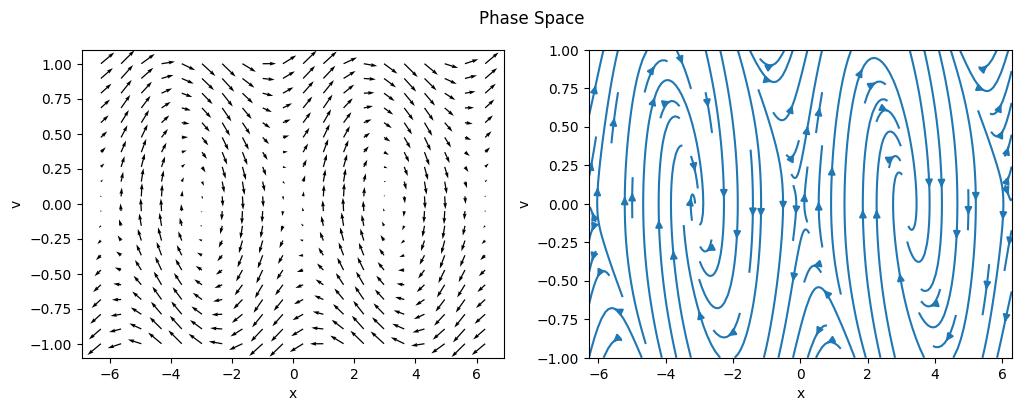

In [9]:
import matplotlib.pyplot as plt
import numpy as np

def accelerator_EOM(phase, ΔE, params:list):
    a0, a1, phi_s = params
    dphase = a0*ΔE
    dE = a1*(np.sin(phase+dphase) - np.sin(phi_s))
    return dphase, dE

params = [1, 1, 0]
linspace_phi = np.linspace(-2*np.pi, 2*np.pi, 20)
linspace_ΔE = np.linspace(-1, 1, 20)

phase, ΔE = np.meshgrid(linspace_phi, linspace_ΔE) 

def get_points(X, V, func, params):
    dx, dv =  np.zeros(X.shape), np.zeros(V.shape)

    xlim, ylim = X.shape
    for i in range(xlim):
        for j in range(ylim):
            xloc = X[i,j]
            vloc = V[i,j]
            dx[i,j], dv[i,j] = func(xloc, vloc, params)
    
    return(dx, dv)


def make_phase_space(X, V, dx, dv):
    fig = plt.figure(figsize = (12,4))
    plt.subplot(1,2,1)
    plt.quiver(X,V,dx,dv)
    plt.xlabel("x")
    plt.ylabel("v")
    plt.subplot(1,2,2)
    plt.streamplot(X,V,dx,dv)
    plt.xlabel("x")
    plt.ylabel("v")
    plt.suptitle("Phase Space")
    plt.show()

dPhase, dΔE = get_points(phase, ΔE, accelerator_EOM, params)
make_phase_space(phase, ΔE, dPhase, dΔE)

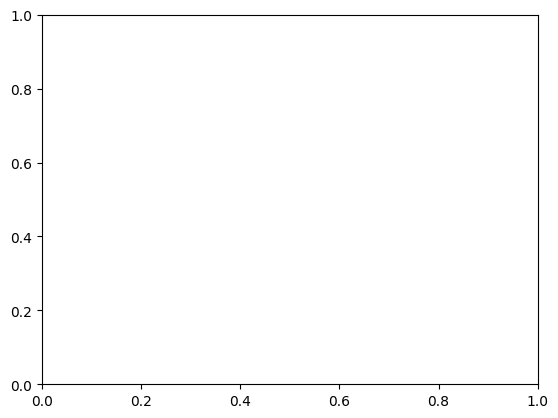

In [10]:
from matplotlib.animation import PillowWriter
import matplotlib.pyplot as plt
import numpy as np
from numpy import cos, pi
from scipy.integrate import solve_ivp

linspace_phi = np.linspace(-2*np.pi, 4*np.pi, 30)
linspace_ΔE = np.linspace(-1, 1, 20)

phase, ΔE = np.meshgrid(linspace_phi, linspace_ΔE) 


def accelerator_EOM(t, p0, params:list):
    phase, ΔE = p0
    a0, a1, ramp_rate = params
    phi_s = ramp_rate*t

    dphase = a0*ΔE
    dE = a1*(np.sin(phase+dphase) - np.sin(phi_s))
    return dphase, dE


fig = plt.figure()
#field1 = plt.quiver(phase, ΔE, dPhase, dΔE)

# creating the animation
metadata = dict(title='Movie', artist='AndrewKoren')
writer = PillowWriter(fps=15, metadata=metadata)

data = []

initial_condition = [0.2, 0.2]
end = 30
dt = 0.3

params = [1, 1, 2*np.pi/end]

tspan = np.arange(0, end, dt)
solution = solve_ivp(accelerator_EOM, (0, end), initial_condition, t_eval = tspan, args=[params])

with writer.saving(fig, 'stability.gif', 100):
    for i, tval in enumerate(tspan):
        
        dPhase, dΔE = accelerator_EOM(tval, (phase, ΔE), params)
        phi_c = tval*params[-1]
        plt.title(fr'$\phi_c$ = {phi_c:.1f}$\pi$')
        plt.xlabel(r'$\phi$ relative to reference')
        plt.ylabel(r'$\Delta E$')
        plt.xlim(-2*pi, 2*pi)
        plt.streamplot(phase-phi_c, ΔE, dPhase, dΔE, color='blue')

        #field1.set_UVC(dPhase, dΔE)

        #plt.plot(solution.y[0][:i+1], solution.y[1][:i+1], color='red')
        writer.grab_frame()
        plt.cla()


Phase space plotting. 

x,px. Note xscale will scale x, but scale will scale y.


---
 G4BL
---

Default is FTFP_Bert.

6.2 Beam

```g4bl
beam gaussian arg1=v1
```
`gaussian` can be replaced with the other types. The args are listed in the reference. `Xp` and `Yp` are relative $x' = p_x/p_0$. ASCII = text file input, same as bmad. Root is smaller but unreadable. Neagtive sigma is half-width instead. PDGid comes from PDG, some stored. Common particles are on pg 185.

l=mm, p=MeV/c, t=ns.

3 Basic concepts. Global coordinates are lab frame, local is relative to objects, usually based at center of object. `radiusCut` marks the end of an element transverse. `particleFilter` kills after condition is met.

Rotation applies rotations in order relative to global coordinates. 
